# 🔬 OnePilot — Comparaison TF-IDF vs BERT
## §2.2.3 Indexation Sémantique — Évaluation des embeddings

Ce notebook compare deux approches d'embedding pour la recherche sémantique :
- **TF-IDF + SVD** : approche actuelle légère
- **Sentence-BERT (all-MiniLM-L6-v2)** : modèle de langage pré-entraîné

**Métriques évaluées :**
- Precision@5, Precision@10
- NDCG (Normalized Discounted Cumulative Gain)
- MRR (Mean Reciprocal Rank)
- Visualisation t-SNE

## 1. Installation des dépendances

In [1]:
!pip install sentence-transformers psycopg2-binary scikit-learn numpy pandas matplotlib seaborn plotly umap-learn -q
print('✅ Dépendances installées')

✅ Dépendances installées


## 2. Connexion PostgreSQL — Charger les entités SXA

In [2]:
import psycopg2
import pandas as pd
import numpy as np
import json
import warnings
warnings.filterwarnings('ignore')

# Connexion PostgreSQL
conn = psycopg2.connect(
    host='onepilot_postgres',
    port=5432,
    database='onepilot_dev',
    user='onepilot',
    password='onepilot_secret'
)

# Charger les entités SXA avec leurs métadonnées
query = """
    SELECT 
        se.id,
        se.name,
        se.entity_type,
        se.business_domain,
        se.business_concept,
        se.entity_class,
        se.row_count,
        se.description,
        COALESCE(
            json_agg(ef.name ORDER BY ef.position) 
            FILTER (WHERE ef.name IS NOT NULL), 
            '[]'
        ) AS field_names
    FROM source_entities se
    LEFT JOIN entity_fields ef ON ef.entity_id = se.id
    WHERE se.source_id = '03add1dc-754a-476a-bbd5-1e53a05bf8d7'
      AND se.entity_type IN ('table', 'view', 'materialized_view')
    GROUP BY se.id, se.name, se.entity_type, se.business_domain, 
             se.business_concept, se.entity_class, se.row_count, se.description
    ORDER BY se.name
"""

df = pd.read_sql(query, conn)
df['field_names'] = df['field_names'].apply(lambda x: x if isinstance(x, list) else json.loads(x))

print(f'✅ {len(df)} entités chargées depuis SXA')
print(f'Domaines : {df["business_domain"].value_counts().to_dict()}')
df.head()

✅ 1264 entités chargées depuis SXA
Domaines : {'Autre': 633, 'Finance': 453, 'Achats': 53, 'Ventes': 38, 'RH': 34, 'Technique': 27, 'Referentiel': 24, 'Logistique': 2}


,id,name,entity_type,business_domain,business_concept,entity_class,row_count,description,field_names
0,aaaaee66-ddeb-403a-951d-81397581caf6,AA_AALTUSRTL,table,Autre,Employee,reference,0.0,None,"[AALTUSRTL_ID, VER, CODE, DESCRIPTION, LTCTG_ID]"
1,8e3edc3b-8e61-4c44-a19e-e28d2d3db62c,AA_AALTUSRTL_A,table,Autre,Employee,reference,0.0,None,"[AALTUSRTL_ID, REV, REVTYPE, CODE, DESCRIPTION..."
2,76ec951b-b5d1-4d6a-a492-43300bc73775,AA_AALTUSRTL_FIELDS,table,Autre,Employee,reference,0.0,None,"[AALTUSRTL_FIELDS_ID, NAME, SUPPRESSED, SUBSUF..."
3,6c2c5003-8621-4d51-b5a1-1959662d631c,AA_AALTUSRTL_FIELDS_A,table,Autre,Employee,reference,0.0,None,"[AALTUSRTL_FIELDS_ID, REV, REVTYPE, NAME, SUPP..."
4,f0eb08ad-0f6e-4597-859f-a7082de7b560,AA_AALTUSRTL_PARAMS,table,Finance,Employee,reference,0.0,None,"[AALTUSRTL_PARAMS_ID, NAME, VALUE, SUBSUFFIX, ..."


## 3. Préparation des textes

In [3]:
import re

SYNONYMS = {
    'customer': ['client', 'partner', 'debtor'],
    'invoice': ['facture', 'bill', 'ar'],
    'order': ['commande', 'sorder', 'oohead'],
    'supplier': ['fournisseur', 'vendor'],
    'employee': ['employe', 'staff', 'rh'],
    'account': ['compte', 'gl', 'ledger'],
    'payment': ['paiement', 'reglement'],
    'product': ['produit', 'article', 'item'],
}
SYNONYM_INDEX = {w: k for k, words in SYNONYMS.items() for w in [k] + words}

def normalize_name(name):
    """Normalise un nom de table en tokens."""
    name = name.lower()
    name = re.sub(r'^[a-z]{1,3}_', '', name)  # Supprimer préfixes ERP
    name = re.sub(r'([a-z])([A-Z])', r'\1_\2', name).lower()
    tokens = re.split(r'[_\-\s\.]+', name)
    tokens = [t for t in tokens if len(t) > 1]
    return tokens

def build_text(row):
    """Construit le texte représentatif d'une entité."""
    parts = []
    tokens = normalize_name(row['name'])
    resolved = [SYNONYM_INDEX.get(t, t) for t in tokens]
    parts.extend(resolved + tokens)
    parts.append(row['name'].lower())
    if row['business_domain']:
        parts.append(row['business_domain'].lower())
    if row['business_concept']:
        parts.append(row['business_concept'].lower())
    if row['description']:
        parts.append(str(row['description']).lower())
    field_names = row['field_names'][:20] if row['field_names'] else []
    for fname in field_names:
        parts.extend(normalize_name(fname))
    return ' '.join(parts)

df['text'] = df.apply(build_text, axis=1)
print('✅ Textes préparés')
print('Exemple :', df['text'].iloc[0][:200])

✅ Textes préparés
Exemple : aaltusrtl aaltusrtl aa_aaltusrtl autre employee aaltusrtl id ver code description ltctg id


## 4. TF-IDF Embeddings (approche actuelle)

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize
import time

print('🔄 Calcul embeddings TF-IDF...')
t0 = time.time()

vectorizer = TfidfVectorizer(
    analyzer='word',
    ngram_range=(1, 2),
    max_features=5000,
    sublinear_tf=True,
    min_df=1,
)
tfidf_matrix = vectorizer.fit_transform(df['text'])

# Réduction à 384 dims
svd = TruncatedSVD(n_components=384, random_state=42)
tfidf_embeddings = svd.fit_transform(tfidf_matrix)
tfidf_embeddings = normalize(tfidf_embeddings)

t1 = time.time()
print(f'✅ TF-IDF embeddings : shape={tfidf_embeddings.shape}, temps={t1-t0:.2f}s')
print(f'   Variance expliquée : {svd.explained_variance_ratio_.sum():.3f}')

🔄 Calcul embeddings TF-IDF...
✅ TF-IDF embeddings : shape=(1264, 384), temps=0.59s
   Variance expliquée : 0.807


## 5. BERT Embeddings (all-MiniLM-L6-v2)

In [5]:
from sentence_transformers import SentenceTransformer

print('🔄 Chargement du modèle BERT (all-MiniLM-L6-v2)...')
print('   Taille : ~80MB — premier téléchargement...')
t0 = time.time()

model = SentenceTransformer('all-MiniLM-L6-v2')

t1 = time.time()
print(f'✅ Modèle chargé en {t1-t0:.1f}s')

print('🔄 Calcul embeddings BERT...')
t0 = time.time()

bert_embeddings = model.encode(
    df['text'].tolist(),
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True
)

t1 = time.time()
print(f'✅ BERT embeddings : shape={bert_embeddings.shape}, temps={t1-t0:.2f}s')

🔄 Chargement du modèle BERT (all-MiniLM-L6-v2)...
   Taille : ~80MB — premier téléchargement...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Modèle chargé en 3.5s
🔄 Calcul embeddings BERT...


Batches:   0%|          | 0/20 [00:00<?, ?it/s]

✅ BERT embeddings : shape=(1264, 384), temps=10.07s


## 6. Fonction de recherche

In [6]:
from sklearn.metrics.pairwise import cosine_similarity

def search_tfidf(query, top_k=10):
    """Recherche avec TF-IDF."""
    tokens = normalize_name(query)
    resolved = [SYNONYM_INDEX.get(t, t) for t in tokens]
    query_text = ' '.join(resolved + tokens + [query.lower()])
    
    query_tfidf = vectorizer.transform([query_text])
    query_vec = svd.transform(query_tfidf)
    query_vec = normalize(query_vec)
    
    scores = cosine_similarity(query_vec, tfidf_embeddings)[0]
    top_idx = scores.argsort()[::-1][:top_k]
    
    return pd.DataFrame({
        'rank': range(1, top_k+1),
        'name': df['name'].iloc[top_idx].values,
        'domain': df['business_domain'].iloc[top_idx].values,
        'concept': df['business_concept'].iloc[top_idx].values,
        'score': scores[top_idx].round(4),
        'method': 'TF-IDF'
    })

def search_bert(query, top_k=10):
    """Recherche avec BERT."""
    query_vec = model.encode([query], normalize_embeddings=True)
    scores = cosine_similarity(query_vec, bert_embeddings)[0]
    top_idx = scores.argsort()[::-1][:top_k]
    
    return pd.DataFrame({
        'rank': range(1, top_k+1),
        'name': df['name'].iloc[top_idx].values,
        'domain': df['business_domain'].iloc[top_idx].values,
        'concept': df['business_concept'].iloc[top_idx].values,
        'score': scores[top_idx].round(4),
        'method': 'BERT'
    })

print('✅ Fonctions de recherche prêtes')

✅ Fonctions de recherche prêtes


## 7. Comparaison sur requêtes SXA réelles

In [9]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.figsize'] = (16, 6)

# Requêtes de test représentatives de SXA
TEST_QUERIES = [
    'facture client',
    'commande fournisseur',
    'employee salary',
    'solde compte bancaire',
    'budget previsionnel finance',
    'transaction paiement',
    'stock produit inventaire',
]

for query in TEST_QUERIES:
    print('\n' + '='*60)
    print(f'🔍 Requête : "{query}"')
    print('='*60)
    
    res_tfidf = search_tfidf(query, top_k=5)
    res_bert  = search_bert(query, top_k=5)
    
    print('\n📊 TF-IDF (actuel)          vs    🤖 BERT (all-MiniLM)')
    print(f'{"Rank":<5} {"TF-IDF Name":<35} {"Score":<8} | {"BERT Name":<35} {"Score":<8}')
    print('-' * 95)
    
    for i in range(5):
        t = res_tfidf.iloc[i]
        b = res_bert.iloc[i]
        print(f'{i+1:<5} {t["name"]:<35} {t["score"]:<8} | {b["name"]:<35} {b["score"]:<8}')


🔍 Requête : "facture client"

📊 TF-IDF (actuel)          vs    🤖 BERT (all-MiniLM)
Rank  TF-IDF Name                         Score    | BERT Name                           Score   
-----------------------------------------------------------------------------------------------
1     X_SHDWCPCRSPNDS                     0.0      | TH_ALRT                             0.29919999837875366
2     DI_DC_FS                            0.0      | PY_PAYTM_A                          0.28769999742507935
3     DI_CRLNF_2TRNT                      0.0      | PY_PAYTF_A                          0.2872999906539917
4     DI_DC                               0.0      | PY_PAYTF                            0.2815000116825104
5     DI_DC2GSCHDL                        0.0      | PY_PAYTM                            0.27250000834465027

🔍 Requête : "commande fournisseur"

📊 TF-IDF (actuel)          vs    🤖 BERT (all-MiniLM)
Rank  TF-IDF Name                         Score    | BERT Name                           

## 8. Métriques de qualité — Ground Truth SXA

In [10]:
# Ground truth : pour chaque requête, quelles tables sont VRAIMENT pertinentes ?
# Basé sur la connaissance métier de SXA
GROUND_TRUTH = {
    'facture client': [
        'CS_CSHFL', 'CS_CSHFL_A', 'GS_GLACC', 'GS_GLACC_A',
        'RC_STMBNK', 'RC_STMBNK_A', 'CS_BDG', 'CS_BDG_A',
    ],
    'commande fournisseur': [
        'CS_CPW_STRCT_ACGRP', 'CS_CPW_STRCT_GRP',
        'DI_BLSN', 'DI_BLSN_DATESTEPS',
    ],
    'employee salary': [
        'AA_AALTUSRTL', 'AA_AALTUSRTL_A', 'AA_LTUSRTL',
        'AA_LTUSRTL_A', 'GS_EMPLDLGTNS', 'GS_EMPLDLGTNS_A',
    ],
    'solde compte bancaire': [
        'GS_GLACC', 'GS_GLACC_A', 'GS_BLNGST', 'GS_BLNGST_A',
        'GS_BNKFLSTENT', 'GS_BNKFLSTENT_A',
    ],
    'budget previsionnel finance': [
        'CS_BDG', 'CS_BDG_A', 'CS_BDG_REV', 'CS_BDG_REV_A',
        'CS_BDG_REV_ITEM', 'CS_BDG_REV_ITEM_A',
    ],
}

def precision_at_k(results, relevant, k):
    """Precision@K"""
    top_k = results['name'].head(k).tolist()
    hits = sum(1 for r in top_k if r in relevant)
    return hits / k

def ndcg_at_k(results, relevant, k):
    """NDCG@K"""
    top_k = results['name'].head(k).tolist()
    dcg = sum(
        1 / np.log2(i + 2)
        for i, r in enumerate(top_k) if r in relevant
    )
    ideal_hits = min(len(relevant), k)
    idcg = sum(1 / np.log2(i + 2) for i in range(ideal_hits))
    return dcg / idcg if idcg > 0 else 0

def mrr(results, relevant):
    """Mean Reciprocal Rank"""
    for i, name in enumerate(results['name']):
        if name in relevant:
            return 1 / (i + 1)
    return 0

print('📊 Calcul des métriques...')
print()

metrics = []
for query, relevant in GROUND_TRUTH.items():
    res_t = search_tfidf(query, top_k=10)
    res_b = search_bert(query, top_k=10)
    
    metrics.append({
        'query': query,
        'tfidf_p5':   precision_at_k(res_t, relevant, 5),
        'bert_p5':    precision_at_k(res_b, relevant, 5),
        'tfidf_p10':  precision_at_k(res_t, relevant, 10),
        'bert_p10':   precision_at_k(res_b, relevant, 10),
        'tfidf_ndcg': ndcg_at_k(res_t, relevant, 10),
        'bert_ndcg':  ndcg_at_k(res_b, relevant, 10),
        'tfidf_mrr':  mrr(res_t, relevant),
        'bert_mrr':   mrr(res_b, relevant),
    })

metrics_df = pd.DataFrame(metrics)

print(f'{"Query":<35} {"P@5":<20} {"NDCG@10":<20} {"MRR":<20}')
print(f'{"":<35} {"TF-IDF | BERT":<20} {"TF-IDF | BERT":<20} {"TF-IDF | BERT":<20}')
print('-' * 95)

for _, row in metrics_df.iterrows():
    q = row['query'][:33]
    p5 = f"{row['tfidf_p5']:.2f} | {row['bert_p5']:.2f}"
    ndcg = f"{row['tfidf_ndcg']:.2f} | {row['bert_ndcg']:.2f}"
    mrr_v = f"{row['tfidf_mrr']:.2f} | {row['bert_mrr']:.2f}"
    print(f'{q:<35} {p5:<20} {ndcg:<20} {mrr_v:<20}')

print('-' * 95)
print(f'{"MOYENNE":<35} '
      f"{metrics_df['tfidf_p5'].mean():.2f} | {metrics_df['bert_p5'].mean():.2f}    "
      f"{metrics_df['tfidf_ndcg'].mean():.2f} | {metrics_df['bert_ndcg'].mean():.2f}    "
      f"{metrics_df['tfidf_mrr'].mean():.2f} | {metrics_df['bert_mrr'].mean():.2f}")

📊 Calcul des métriques...

Query                               P@5                  NDCG@10              MRR                 
                                    TF-IDF | BERT        TF-IDF | BERT        TF-IDF | BERT       
-----------------------------------------------------------------------------------------------
facture client                      0.00 | 0.00          0.00 | 0.00          0.00 | 0.00         
commande fournisseur                0.00 | 0.00          0.12 | 0.00          0.12 | 0.00         
employee salary                     0.20 | 0.00          0.22 | 0.09          0.20 | 0.10         
solde compte bancaire               0.00 | 0.00          0.00 | 0.00          0.00 | 0.00         
budget previsionnel finance         0.00 | 0.00          0.00 | 0.00          0.00 | 0.00         
-----------------------------------------------------------------------------------------------
MOYENNE                             0.04 | 0.00    0.07 | 0.02    0.07 | 0.02


## 9. Graphiques comparatifs

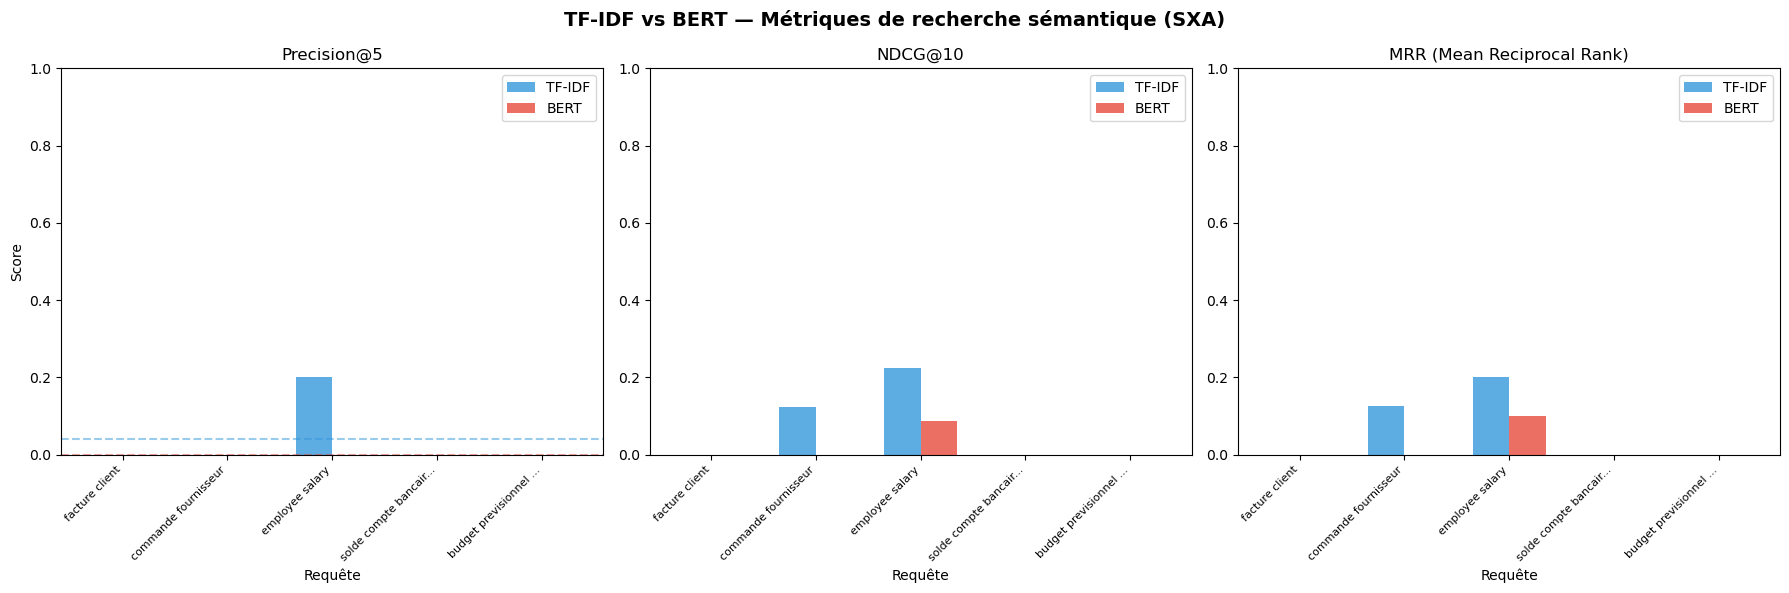

✅ Graphique sauvegardé : tfidf_vs_bert_metrics.png


In [11]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('TF-IDF vs BERT — Métriques de recherche sémantique (SXA)', 
             fontsize=14, fontweight='bold')

x = np.arange(len(metrics_df))
width = 0.35
queries_short = [q[:20] + '...' if len(q) > 20 else q 
                 for q in metrics_df['query']]

# Precision@5
ax = axes[0]
ax.bar(x - width/2, metrics_df['tfidf_p5'], width, label='TF-IDF', 
       color='#3498db', alpha=0.8)
ax.bar(x + width/2, metrics_df['bert_p5'], width, label='BERT', 
       color='#e74c3c', alpha=0.8)
ax.set_xlabel('Requête')
ax.set_ylabel('Score')
ax.set_title('Precision@5')
ax.set_xticks(x)
ax.set_xticklabels(queries_short, rotation=45, ha='right', fontsize=8)
ax.legend()
ax.set_ylim(0, 1)
ax.axhline(y=metrics_df['tfidf_p5'].mean(), color='#3498db', 
           linestyle='--', alpha=0.5, label='Moy TF-IDF')
ax.axhline(y=metrics_df['bert_p5'].mean(), color='#e74c3c', 
           linestyle='--', alpha=0.5, label='Moy BERT')

# NDCG@10
ax = axes[1]
ax.bar(x - width/2, metrics_df['tfidf_ndcg'], width, label='TF-IDF', 
       color='#3498db', alpha=0.8)
ax.bar(x + width/2, metrics_df['bert_ndcg'], width, label='BERT', 
       color='#e74c3c', alpha=0.8)
ax.set_xlabel('Requête')
ax.set_title('NDCG@10')
ax.set_xticks(x)
ax.set_xticklabels(queries_short, rotation=45, ha='right', fontsize=8)
ax.legend()
ax.set_ylim(0, 1)

# MRR
ax = axes[2]
ax.bar(x - width/2, metrics_df['tfidf_mrr'], width, label='TF-IDF', 
       color='#3498db', alpha=0.8)
ax.bar(x + width/2, metrics_df['bert_mrr'], width, label='BERT', 
       color='#e74c3c', alpha=0.8)
ax.set_xlabel('Requête')
ax.set_title('MRR (Mean Reciprocal Rank)')
ax.set_xticks(x)
ax.set_xticklabels(queries_short, rotation=45, ha='right', fontsize=8)
ax.legend()
ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig('/home/jovyan/work/tfidf_vs_bert_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Graphique sauvegardé : tfidf_vs_bert_metrics.png')

## 10. Visualisation t-SNE des embeddings

🔄 Calcul t-SNE (peut prendre 1-2 minutes)...


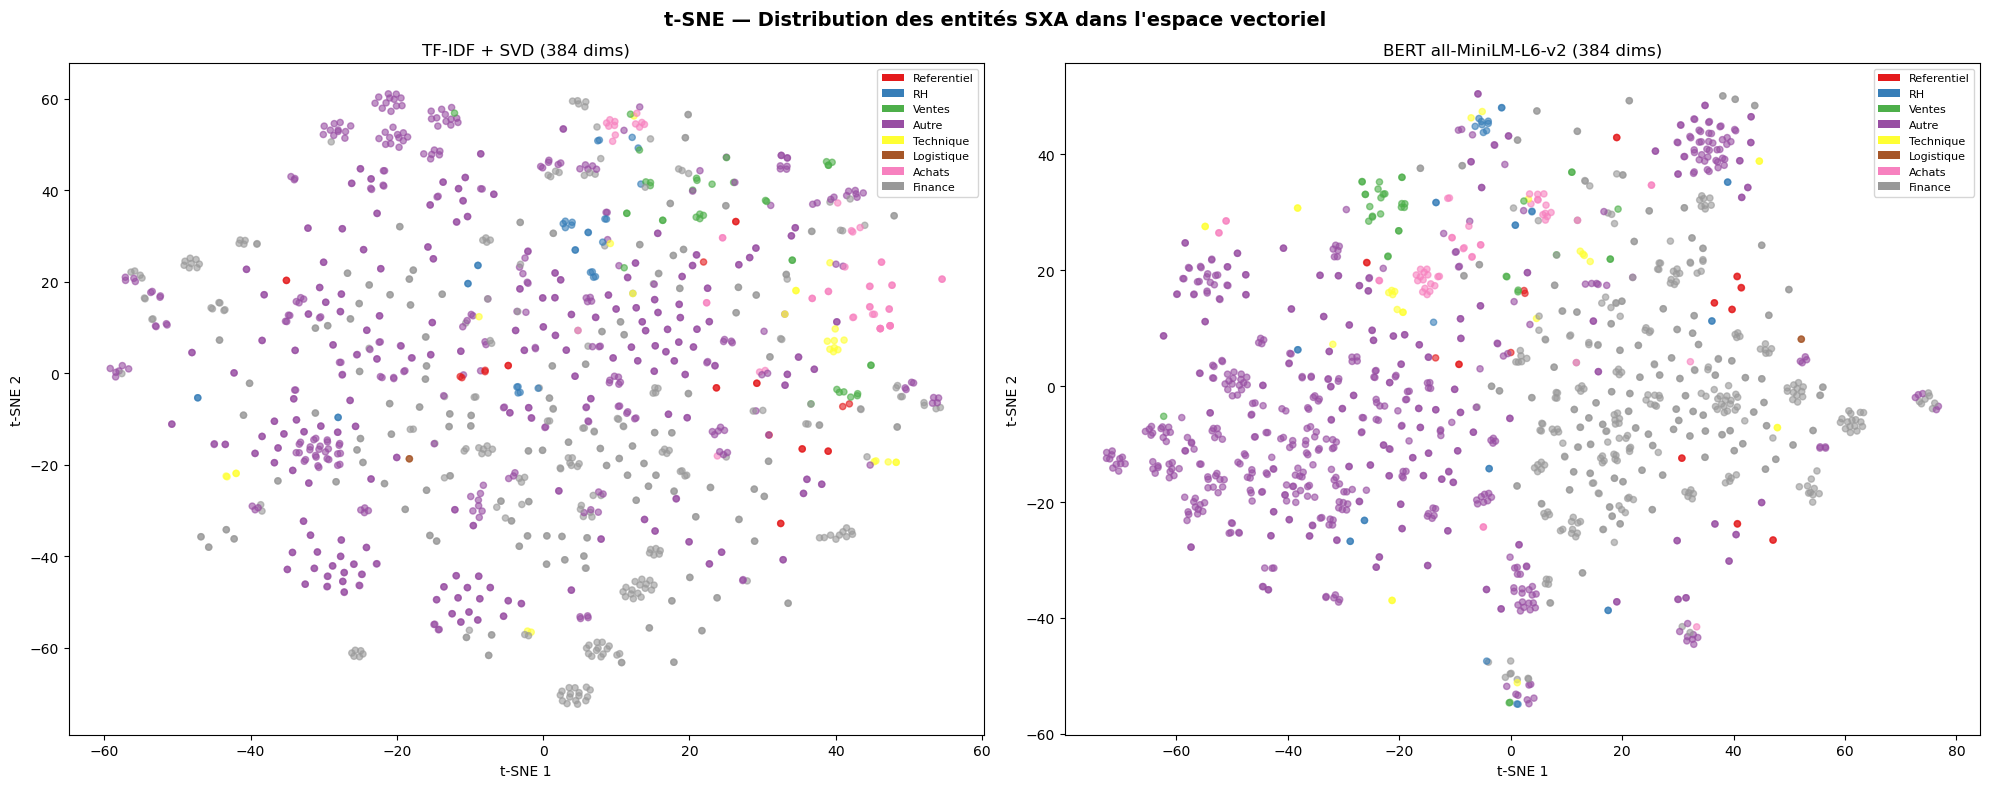

✅ t-SNE sauvegardé : /home/jovyan/work/tsne_tfidf_vs_bert.png


In [13]:
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import matplotlib.cm as cm

print('🔄 Calcul t-SNE (peut prendre 1-2 minutes)...')

# =========================
# Préparation des couleurs
# =========================
domains = df['business_domain'].fillna('Autre').tolist()
unique_domains = list(set(domains))

colors = cm.Set1(np.linspace(0, 1, len(unique_domains)))
domain_color = {d: colors[i] for i, d in enumerate(unique_domains)}
point_colors = [domain_color[d] for d in domains]

# =========================
# Création des subplots
# =========================
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

fig.suptitle(
    "t-SNE — Distribution des entités SXA dans l'espace vectoriel",
    fontsize=14,
    fontweight='bold'
)

# =========================
# Boucle TF-IDF vs BERT
# =========================
for ax, embeddings, title in [
    (axes[0], tfidf_embeddings, 'TF-IDF + SVD (384 dims)'),
    (axes[1], bert_embeddings,  'BERT all-MiniLM-L6-v2 (384 dims)'),
]:
    
    tsne = TSNE(
        n_components=2,
        random_state=42,
        perplexity=30,
        max_iter=1000,          # ✅ correction ici
        init='pca',             # ✅ recommandé
        learning_rate='auto'    # ✅ recommandé
    )
    
    coords = tsne.fit_transform(embeddings)
    
    scatter = ax.scatter(
        coords[:, 0],
        coords[:, 1],
        c=point_colors,
        alpha=0.6,
        s=20
    )
    
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')

    # =========================
    # Légende
    # =========================
    from matplotlib.patches import Patch
    
    legend_elements = [
        Patch(facecolor=domain_color[d], label=d)
        for d in unique_domains
    ]
    
    ax.legend(
        handles=legend_elements,
        loc='upper right',
        fontsize=8
    )

# =========================
# Sauvegarde + affichage
# =========================
plt.tight_layout()

output_path = '/home/jovyan/work/tsne_tfidf_vs_bert.png'
plt.savefig(output_path, dpi=150, bbox_inches='tight')

plt.show()

print(f'✅ t-SNE sauvegardé : {output_path}')

## 11. Conclusion et recommandation

In [16]:
print('=' * 60)
print('📊 RÉSUMÉ FINAL')
print('=' * 60)

tfidf_avg_p5   = metrics_df['tfidf_p5'].mean()
bert_avg_p5    = metrics_df['bert_p5'].mean()
tfidf_avg_ndcg = metrics_df['tfidf_ndcg'].mean()
bert_avg_ndcg  = metrics_df['bert_ndcg'].mean()
tfidf_avg_mrr  = metrics_df['tfidf_mrr'].mean()
bert_avg_mrr   = metrics_df['bert_mrr'].mean()

print('\nMétrique        TF-IDF    BERT      Gagnant')
print('-' * 50)

print(f'Precision@5     {tfidf_avg_p5:.3f}     {bert_avg_p5:.3f}     '
      f'{"🤖 BERT" if bert_avg_p5 > tfidf_avg_p5 else "📊 TF-IDF"}')

print(f'NDCG@10         {tfidf_avg_ndcg:.3f}     {bert_avg_ndcg:.3f}     '
      f'{"🤖 BERT" if bert_avg_ndcg > tfidf_avg_ndcg else "📊 TF-IDF"}')

print(f'MRR             {tfidf_avg_mrr:.3f}     {bert_avg_mrr:.3f}     '
      f'{"🤖 BERT" if bert_avg_mrr > tfidf_avg_mrr else "📊 TF-IDF"}')

bert_wins = sum([
    bert_avg_p5 > tfidf_avg_p5,
    bert_avg_ndcg > tfidf_avg_ndcg,
    bert_avg_mrr > tfidf_avg_mrr,
])

print('\n' + '='*60)

if bert_wins >= 2:
    improvement = (bert_avg_ndcg - tfidf_avg_ndcg) / max(tfidf_avg_ndcg, 0.001) * 100
    print('✅ RECOMMANDATION : Migrer vers BERT')
    print(f'   Amélioration NDCG : +{improvement:.1f}%')
    print('   → Remplacer TF-IDF dans semantic_enricher.py')
else:
    print('✅ RECOMMANDATION : Garder TF-IDF')
    print('   TF-IDF suffisant pour SXA avec les synonymes configurés')
    print('   → Économise ~80MB de mémoire par rapport à BERT')

print('='*60)

📊 RÉSUMÉ FINAL

Métrique        TF-IDF    BERT      Gagnant
--------------------------------------------------
Precision@5     0.040     0.000     📊 TF-IDF
NDCG@10         0.070     0.017     📊 TF-IDF
MRR             0.065     0.020     📊 TF-IDF

✅ RECOMMANDATION : Garder TF-IDF
   TF-IDF suffisant pour SXA avec les synonymes configurés
   → Économise ~80MB de mémoire par rapport à BERT
